# 05 - fine tuning y evaluacion final

## Proyecto
**Clasificación de razas de perros y gatos con CNN y Transfer Learning**  
Dataset: **Oxford-IIIT Pet Dataset**

## Objetivo de este notebook
En este notebook construiremos la **versión final** del proyecto usando **fine-tuning** sobre MobileNetV2.

### ¿Qué haremos?
1. cargar y preprocesar el dataset,
2. construir un modelo con **MobileNetV2** preentrenada,
3. entrenar primero la cabeza de clasificación con la base congelada,
4. desbloquear parcialmente la base convolucional,
5. continuar el entrenamiento con una tasa de aprendizaje más baja,
6. evaluar el modelo final en test,
7. analizar resultados con métricas, matriz de confusión y ejemplos de predicción.

### ¿Qué es fine-tuning?
Fine-tuning significa tomar un modelo preentrenado y, después de haber entrenado una nueva cabeza de salida, permitir que algunas capas internas se ajusten al nuevo dataset.  
Esto suele mejorar el rendimiento porque adapta las características visuales del modelo al problema específico.

> Este notebook es autocontenido: puede ejecutarse de forma independiente en Google Colab sin depender del notebook 04.

## 1. Importación de librerías

Usaremos:

- **tensorflow**: para construir y entrenar el modelo.
- **tensorflow_datasets**: para cargar el Oxford-IIIT Pet Dataset.
- **matplotlib** y **seaborn**: para visualización.
- **numpy**: apoyo numérico.
- **scikit-learn**: para el reporte de clasificación y la matriz de confusión.

También fijamos una semilla para mejorar la reproducibilidad.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
sns.set_context("notebook")

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.20.0
TensorFlow Datasets version: 4.9.10


## 2. Carga del dataset

Usaremos la misma partición que en los notebooks anteriores:

- `train[:80%]` para entrenamiento,
- `train[80%:]` para validación,
- `test` para prueba final.

Esto permite comparar los resultados entre baseline, transfer learning y fine-tuning en condiciones consistentes.

In [2]:
dataset_name = "oxford_iiit_pet"

(train_raw, val_raw, test_raw), info = tfds.load(
    dataset_name,
    split=["train[:80%]", "train[80%:]", "test"],
    with_info=True,
    as_supervised=False
)

class_names = info.features["label"].names
num_classes = info.features["label"].num_classes

print("Número de clases:", num_classes)
print("Train:", tf.data.experimental.cardinality(train_raw).numpy())
print("Validation:", tf.data.experimental.cardinality(val_raw).numpy())
print("Test:", tf.data.experimental.cardinality(test_raw).numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Número de clases: 37
Train: 2944
Validation: 736
Test: 3669


## 3. Hiperparámetros

Definimos aquí los parámetros principales del experimento.

### Variables principales
- **IMG_SIZE**: tamaño de entrada de las imágenes.
- **BATCH_SIZE**: tamaño del lote.
- **INITIAL_EPOCHS**: épocas para entrenar la cabeza del clasificador con la base congelada.
- **FINE_TUNE_EPOCHS**: épocas adicionales de fine-tuning.
- **INITIAL_LR**: learning rate para la primera fase.
- **FINE_TUNE_LR**: learning rate más pequeño para la segunda fase.
- **FINE_TUNE_AT**: índice desde el cual se desbloquearán capas de MobileNetV2.

### Comentario
En fine-tuning se usa una tasa de aprendizaje menor porque no queremos destruir las características preentrenadas, sino ajustarlas suavemente.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 6

INITIAL_LR = 1e-3
FINE_TUNE_LR = 1e-5

FINE_TUNE_AT = 100

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("INITIAL_EPOCHS:", INITIAL_EPOCHS)
print("FINE_TUNE_EPOCHS:", FINE_TUNE_EPOCHS)
print("INITIAL_LR:", INITIAL_LR)
print("FINE_TUNE_LR:", FINE_TUNE_LR)
print("FINE_TUNE_AT:", FINE_TUNE_AT)

IMG_SIZE: (224, 224)
BATCH_SIZE: 32
INITIAL_EPOCHS: 8
FINE_TUNE_EPOCHS: 6
INITIAL_LR: 0.001
FINE_TUNE_LR: 1e-05
FINE_TUNE_AT: 100


## 4. Preprocesado específico para MobileNetV2

Como vamos a usar MobileNetV2, debemos aplicar su preprocesado oficial.

### Pasos
1. convertir la imagen a `float32`,
2. redimensionarla a `224x224`,
3. aplicar `tf.keras.applications.mobilenet_v2.preprocess_input`,
4. devolver `(image, label)`.

In [4]:
def preprocess_example_mobilenet(example, img_size=IMG_SIZE):
    image = example["image"]
    label = example["label"]

    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, img_size)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

## 5. Data augmentation

Aplicaremos aumento de datos moderado para ayudar a la generalización del modelo.

Usaremos:
- volteo horizontal,
- pequeña rotación,
- pequeño zoom.

Esto permite que el modelo vea ligeras variaciones de las imágenes durante entrenamiento.

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

## 6. Construcción del pipeline de datos

Usaremos `tf.data` con:
- `map`,
- `cache`,
- `shuffle`,
- `batch`,
- `prefetch`.

Solo el conjunto de entrenamiento se mezcla.

In [6]:
def build_dataset(ds, training=False):
    ds = ds.map(preprocess_example_mobilenet, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()

    if training:
        ds = ds.shuffle(SHUFFLE_BUFFER, seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(train_raw, training=True)
val_ds = build_dataset(val_raw, training=False)
test_ds = build_dataset(test_raw, training=False)

print("Datasets listos.")

Datasets listos.


## 7. Inspección rápida del pipeline

Verificamos que el pipeline entrega tensores con la forma correcta.

In [7]:
images_batch, labels_batch = next(iter(train_ds))

print("Shape imágenes:", images_batch.shape)
print("Shape etiquetas:", labels_batch.shape)
print("Tipo de dato:", images_batch.dtype)
print("Valor mínimo:", tf.reduce_min(images_batch).numpy())
print("Valor máximo:", tf.reduce_max(images_batch).numpy())

Shape imágenes: (32, 224, 224, 3)
Shape etiquetas: (32,)
Tipo de dato: <dtype: 'float32'>
Valor mínimo: -1.0
Valor máximo: 1.0


## 8. Construcción de la base preentrenada

Cargamos **MobileNetV2** con pesos de **ImageNet** y sin la cabeza original de clasificación.

### Parámetros
- `include_top=False`: elimina la salida de ImageNet.
- `weights="imagenet"`: carga pesos preentrenados.
- `input_shape=IMG_SIZE + (3,)`: define el tamaño de entrada.

Inicialmente congelaremos la base convolucional.

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model trainable: False


## 9. Construcción del modelo completo

La estructura será:

1. entrada,
2. data augmentation,
3. base convolucional MobileNetV2,
4. global average pooling,
5. dropout,
6. capa final softmax para 37 clases.

In [9]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="mobilenetv2_fine_tuning")
model.summary()

Model: "mobilenetv2_fine_tuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Compilación para la primera fase

En la primera fase entrenaremos únicamente la cabeza de clasificación.

### Configuración
- optimizador: Adam,
- learning rate inicial: `INITIAL_LR`,
- pérdida: SparseCategoricalCrossentropy,
- métrica: accuracy.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Modelo compilado para fase inicial.")

Modelo compilado para fase inicial.


## 11. Callbacks

Usaremos:
- **EarlyStopping**,
- **ReduceLROnPlateau**.

Esto ayuda a estabilizar el entrenamiento.

In [11]:
initial_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

initial_callbacks

## 12. Primera fase: entrenamiento con base congelada

En esta fase MobileNetV2 funciona como extractor de características fijo, y solo se entrena la capa de clasificación nueva.

In [13]:
history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=initial_callbacks,
    verbose=1
)

Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.5560 - loss: 1.7122 - val_accuracy: 0.8451 - val_loss: 0.6388 - learning_rate: 0.0010
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8329 - loss: 0.5950 - val_accuracy: 0.8804 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.8716 - loss: 0.4343 - val_accuracy: 0.8859 - val_loss: 0.3787 - learning_rate: 0.0010
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8808 - loss: 0.3804 - val_accuracy: 0.8940 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.9066 - loss: 0.3003 - val_accuracy: 0.9062 - val_loss: 0.3243 - learning_rate: 0.0010
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9175 - loss: 0.2746 - val_accuracy: 0.8899 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9348 - loss: 0.2334 - val_accuracy: 

## 13. Preparación para fine-tuning

Ahora desbloquearemos parte de MobileNetV2 para adaptar sus características al dataset.

### Estrategia
1. activar `base_model.trainable = True`,
2. congelar las capas iniciales,
3. dejar entrenables solo las capas más profundas.

### Nota importante
Mantendremos las capas **BatchNormalization** congeladas porque en fine-tuning suelen volverse inestables si se actualizan con datasets pequeños o medianos.

In [14]:
base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in base_model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = np.sum([layer.trainable for layer in base_model.layers])
total_count = len(base_model.layers)

print("Base model trainable:", base_model.trainable)
print("Capas entrenables en base_model:", trainable_count)
print("Capas totales en base_model:", total_count)

Base model trainable: True
Capas entrenables en base_model: 36
Capas totales en base_model: 154


## 14. Recompilación para fine-tuning

Después de cambiar qué capas son entrenables, es obligatorio recompilar el modelo.

### Cambio principal
Usaremos un **learning rate mucho más pequeño** (`FINE_TUNE_LR`) para ajustar suavemente los pesos preentrenados.

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Modelo recompilado para fine-tuning.")

Modelo recompilado para fine-tuning.


## 15. Callbacks para fine-tuning

Definimos callbacks específicos para la segunda fase.

In [16]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

fine_tune_callbacks

## 16. Segunda fase: fine-tuning

Continuamos el entrenamiento desde la última época alcanzada en la fase inicial.

### Parámetro importante
- `initial_epoch`: indica que esta continuación empieza después de la primera fase.

In [17]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=len(history_initial.history["loss"]),
    callbacks=fine_tune_callbacks,
    verbose=1
)

Epoch 9/14
92/92 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.9361 - loss: 0.1919 - val_accuracy: 0.8913 - val_loss: 0.3233 - learning_rate: 1.0000e-05
Epoch 10/14
92/92 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9382 - loss: 0.1738 - val_accuracy: 0.9008 - val_loss: 0.3081 - learning_rate: 1.0000e-05
Epoch 11/14
92/92 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9440 - loss: 0.1557 - val_accuracy: 0.9062 - val_loss: 0.3020 - learning_rate: 1.0000e-05
Epoch 12/14
92/92 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.9501 - loss: 0.1366 - val_accuracy: 0.9008 - val_loss: 0.3195 - learning_rate: 1.0000e-05
Epoch 13/14
92/92 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.9572 - loss: 0.1349 - val_accuracy: 0.9090 - val_loss: 0.3102 - learning_rate: 1.0000e-05
Epoch 14/14
92/92 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.9558 - loss: 0.1276 - val_accuracy: 0.9008 - val_loss: 0.3150 - learning_rate: 5.0000e-06


## 17. Combinación de historiales de entrenamiento

Como entrenamos en dos fases, combinaremos sus historiales para visualizar la evolución completa.

In [18]:
full_history = {}
for key in history_initial.history.keys():
    full_history[key] = history_initial.history[key] + history_fine.history[key]

## 18. Curvas completas de entrenamiento

Visualizaremos:
- pérdida de entrenamiento y validación,
- accuracy de entrenamiento y validación.

Además, marcaremos visualmente el punto donde comenzó el fine-tuning.

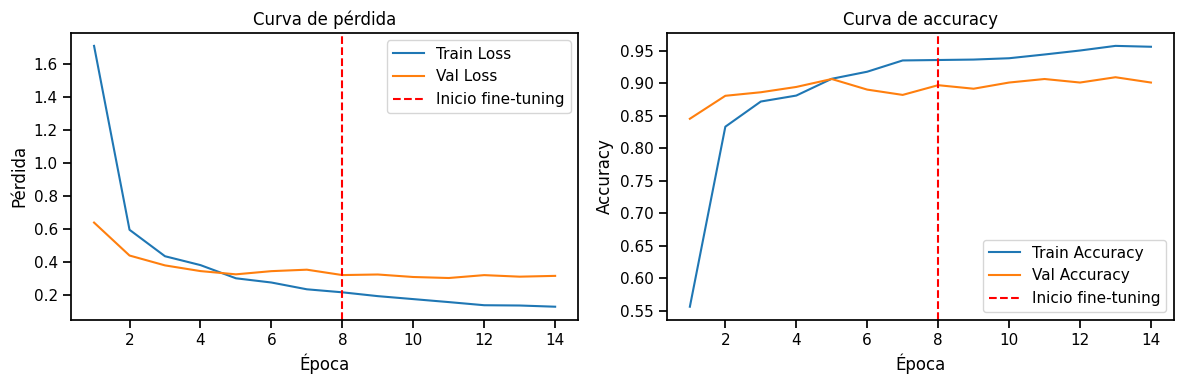

In [19]:
def plot_full_history(full_history, initial_epochs):
    epochs_range = range(1, len(full_history["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, full_history["loss"], label="Train Loss")
    plt.plot(epochs_range, full_history["val_loss"], label="Val Loss")
    plt.axvline(initial_epochs, color="red", linestyle="--", label="Inicio fine-tuning")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title("Curva de pérdida")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, full_history["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, full_history["val_accuracy"], label="Val Accuracy")
    plt.axvline(initial_epochs, color="red", linestyle="--", label="Inicio fine-tuning")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Curva de accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_full_history(full_history, INITIAL_EPOCHS)

## 19. Evaluación final en test

Esta será la evaluación final del proyecto sobre el conjunto de prueba.

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8926 - loss: 0.3432
Test Loss: 0.3432
Test Accuracy: 0.8926


## 20. Generación de predicciones sobre test

Obtendremos:
- etiquetas reales,
- etiquetas predichas,
- imágenes del conjunto de prueba para visualización posterior.

In [21]:
y_true = []
y_pred = []
test_images_for_display = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
    test_images_for_display.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Número de ejemplos evaluados:", len(y_true))

Número de ejemplos evaluados: 3669


## 21. Reporte de clasificación

El reporte muestra:
- precision,
- recall,
- f1-score,
- support,

para cada una de las 37 clases.

In [22]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
)

print(report)

                            precision    recall  f1-score   support

                Abyssinian      0.871     0.898     0.884        98
          american_bulldog      0.637     0.930     0.756       100
 american_pit_bull_terrier      0.870     0.470     0.610       100
              basset_hound      0.968     0.910     0.938       100
                    beagle      0.920     0.920     0.920       100
                    Bengal      0.827     0.860     0.843       100
                    Birman      0.737     0.730     0.734       100
                    Bombay      0.918     0.886     0.902        88
                     boxer      0.807     0.889     0.846        99
         British_Shorthair      0.823     0.790     0.806       100
                 chihuahua      0.943     0.830     0.883       100
              Egyptian_Mau      0.950     0.784     0.859        97
    english_cocker_spaniel      0.989     0.930     0.959       100
            english_setter      0.951     0.970

## 22. Matriz de confusión

La matriz de confusión permite observar qué razas se siguen confundiendo incluso después del fine-tuning.

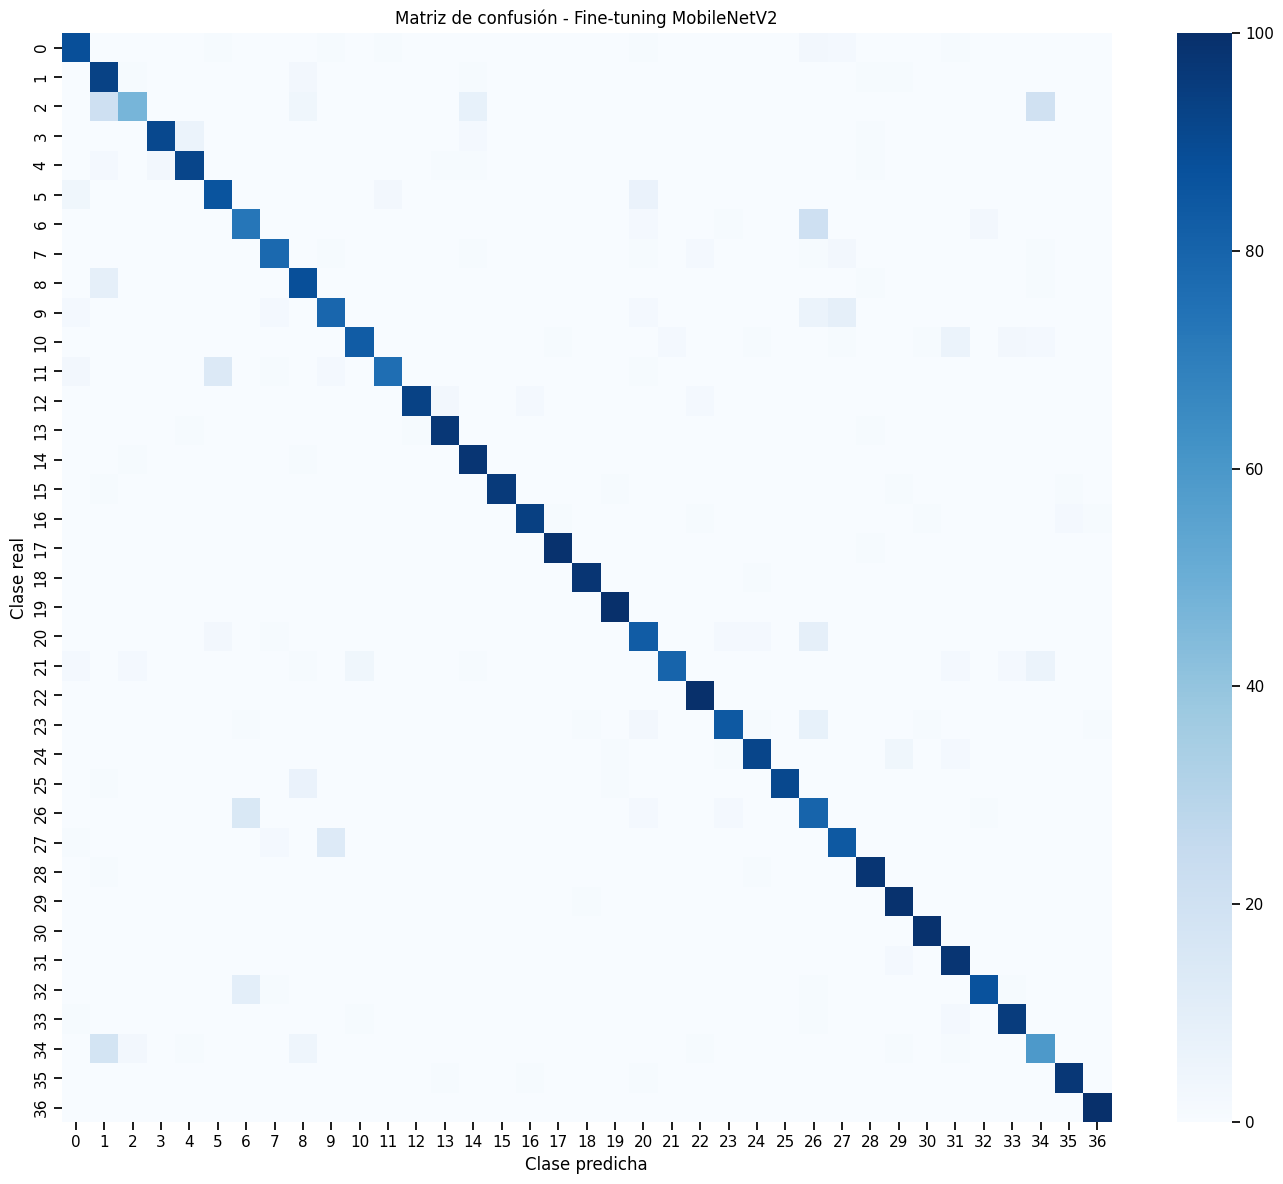

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Matriz de confusión - Fine-tuning MobileNetV2")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

## 23. Visualización de predicciones

Mostramos algunos ejemplos del conjunto de prueba.  
Como las imágenes están en el rango preprocesado de MobileNetV2, las reescalamos solo para visualización.

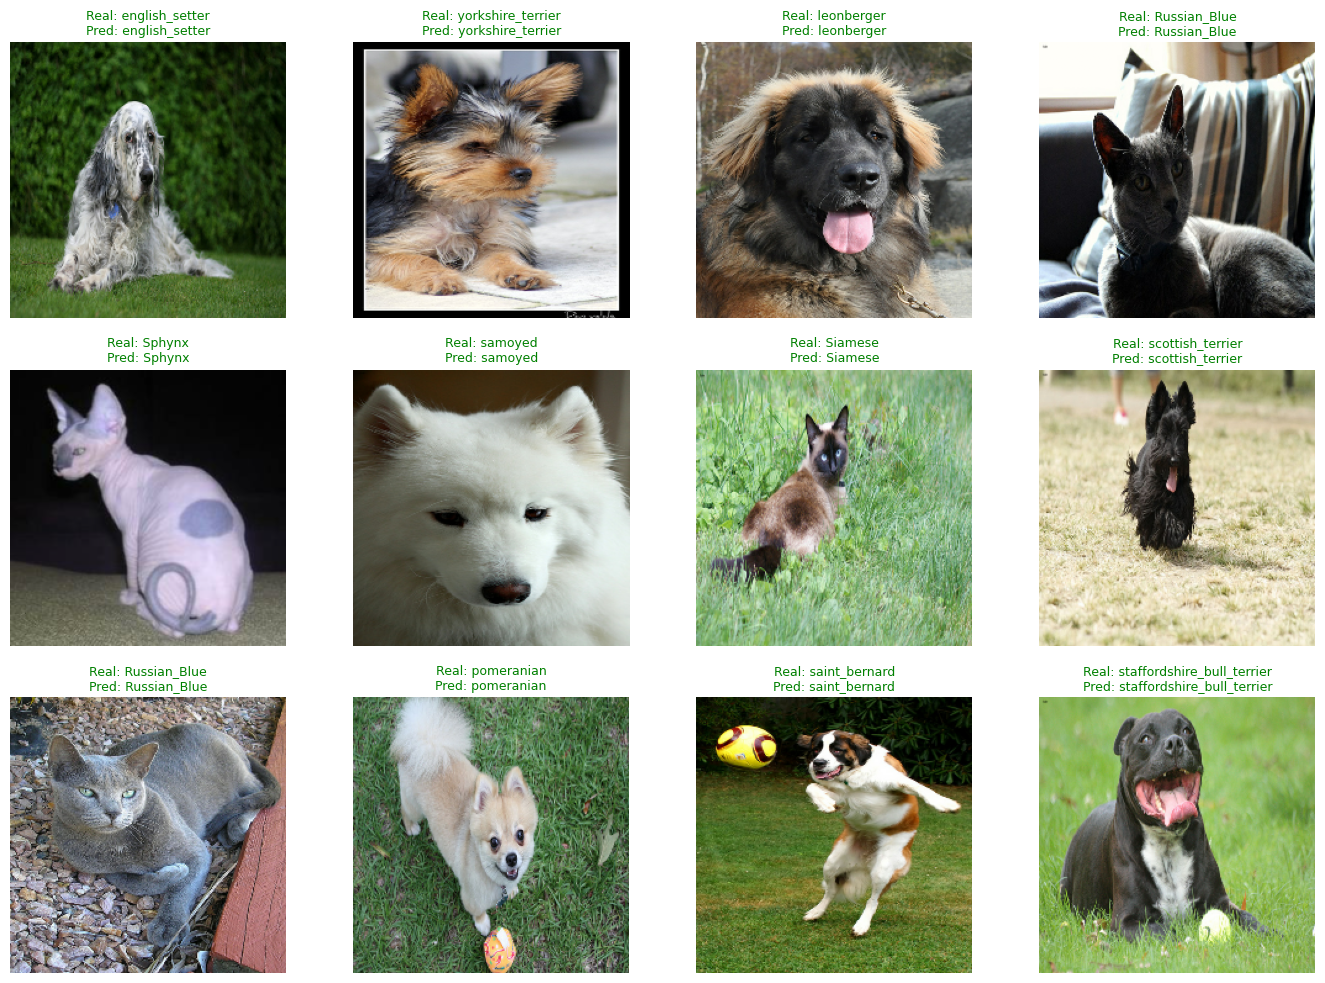

In [24]:
def show_predictions(images, y_true, y_pred, class_names, num_examples=12, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(images), size=num_examples, replace=False)

    plt.figure(figsize=(14, 10))
    for i, idx in enumerate(indices, 1):
        plt.subplot(3, 4, i)

        image = images[idx]
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        plt.imshow(image)

        true_label = class_names[int(y_true[idx])]
        pred_label = class_names[int(y_pred[idx])]
        correct = y_true[idx] == y_pred[idx]
        title_color = "green" if correct else "red"

        plt.title(f"Real: {true_label}\nPred: {pred_label}", color=title_color, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(test_images_for_display, y_true, y_pred, class_names, num_examples=12)

## 24. Comparación cualitativa con etapas anteriores

Conceptualmente, este notebook representa la tercera gran etapa del proyecto:

1. **Baseline CNN**: red sencilla entrenada desde cero.
2. **Transfer learning**: MobileNetV2 congelada + nueva cabeza.
3. **Fine-tuning**: ajuste parcial de MobileNetV2 con learning rate pequeño.

### Qué se espera normalmente
El fine-tuning debería:
- mejorar o al menos refinar la accuracy final,
- reducir algunas confusiones entre clases similares,
- adaptar mejor el extractor de características al dominio del dataset.

## 25. Resumen de resultados finales

Para el informe y la presentación, es útil dejar aquí una tabla resumen con los valores obtenidos en esta fase.

> Completa o ajusta esta tabla con tus resultados reales después de ejecutar el notebook.

In [25]:
summary_results = {
    "Modelo": ["Fine-tuning MobileNetV2"],
    "Test Loss": [test_loss],
    "Test Accuracy": [test_accuracy],
    "Número de clases": [num_classes],
    "Tamaño de imagen": [IMG_SIZE],
    "Épocas fase 1": [len(history_initial.history["loss"])],
    "Épocas fase 2": [len(history_fine.history["loss"])]
}

import pandas as pd
pd.DataFrame(summary_results)

,Modelo,Test Loss,Test Accuracy,Número de clases,Tamaño de imagen,Épocas fase 1,Épocas fase 2
0,Fine-tuning MobileNetV2,0.343214,0.892614,37,"(224, 224)",8,6


## 26. Conclusiones finales del notebook

En este notebook se construyó la versión final del proyecto:

- se partió de MobileNetV2 preentrenada,
- se entrenó primero una nueva cabeza de clasificación,
- luego se aplicó fine-tuning parcial a la base convolucional,
- y finalmente se evaluó el modelo en el conjunto de prueba.

Esta versión puede considerarse la **solución final** del proyecto, ya que combina:
- transfer learning,
- ajuste fino del extractor de características,
- análisis de resultados cuantitativos y cualitativos.